In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from datetime import datetime

In [3]:
import numpy 

In [4]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [5]:
start_date = '2020-01-01'
end_date = datetime.today()

In [6]:
INFY = yf.download('INFY.NS', start=start_date, end=end_date)  # Infosys
Reliance = yf.download('RELIANCE.NS', start=start_date, end=end_date)  # Reliance Industries
HDFC_Bank = yf.download('HDFCBANK.NS', start=start_date, end=end_date)  # HDFC Bank
ICICI_Bank = yf.download('ICICIBANK.NS', start=start_date, end=end_date)  # ICICI Bank
SBI = yf.download('SBIN.NS', start=start_date, end=end_date)  # State Bank of India
Bajaj_Finance = yf.download('BAJFINANCE.NS', start=start_date, end=end_date)  # Bajaj Finance
Bharti_Airtel = yf.download('BHARTIARTL.NS', start=start_date, end=end_date)  # Bharti Airtel
Kotak_Bank = yf.download('KOTAKBANK.NS', start=start_date, end=end_date)  # Kotak Mahindra Bank
L_T = yf.download('LT.NS', start=start_date, end=end_date)  # Larsen & Toubro
ITC = yf.download('ITC.NS', start=start_date, end=end_date)  # ITC Limited
Axis_Bank = yf.download('AXISBANK.NS', start=start_date, end=end_date)  # Axis Bank
Wipro = yf.download('WIPRO.NS', start=start_date, end=end_date)  # Wipro
Maruti = yf.download('MARUTI.NS', start=start_date, end=end_date)  # Maruti Suzuki
Asian_Paints = yf.download('ASIANPAINT.NS', start=start_date, end=end_date)  # Asian Paints
HCL_Tech = yf.download('HCLTECH.NS', start=start_date, end=end_date)  # HCL Technologies
UltraTech_Cement = yf.download('ULTRACEMCO.NS', start=start_date, end=end_date)  # UltraTech Cement
Sun_Pharma = yf.download('SUNPHARMA.NS', start=start_date, end=end_date)  # Sun Pharmaceutical
PowerGrid = yf.download('POWERGRID.NS', start=start_date, end=end_date)  # Power Grid Corporation
TCS = yf.download('TCS.NS', start=start_date, end=end_date)  # Tata Consultancy Services
HINDUNILVR = yf.download('HINDUNILVR.NS', start=start_date, end=end_date)  # Hindustan Unilever


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [7]:
stocks = pd.concat([
    INFY['Adj Close'], Reliance['Adj Close'], HDFC_Bank['Adj Close'], # Changed 'Adj Close' to 'Close'
    ICICI_Bank['Adj Close'], SBI['Adj Close'], Bajaj_Finance['Adj Close'], # Changed 'Adj Close' to 'Close'
    Bharti_Airtel['Adj Close'], Kotak_Bank['Adj Close'], L_T['Adj Close'], # Changed 'Adj Close' to 'Close'
    ITC['Adj Close'], Axis_Bank['Adj Close'], Wipro['Adj Close'], # Changed 'Adj Close' to 'Close'
    Maruti['Adj Close'], Asian_Paints['Adj Close'], HCL_Tech['Adj Close'], # Changed 'Adj Close' to 'Close'
    UltraTech_Cement['Adj Close'], Sun_Pharma['Adj Close'], PowerGrid['Adj Close'], # Changed 'Adj Close' to 'Close'
    TCS['Adj Close'], HINDUNILVR['Adj Close'] # Changed 'Adj Close' to 'Close'
], axis=1)

In [8]:
stocks

,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close
Date,,,,,,,,,,,,,,,,,,,,
2020-01-01,661.20520,668.25537,1227.42859,518.85400,314.79919,4160.83887,436.93896,1669.00745,1203.41040,194.74904,745.45203,117.91528,7020.50732,1723.83618,482.28183,3967.75757,412.52847,81.72218,1983.74756,1795.82141
2020-01-02,659.27582,679.63202,1235.25244,522.57562,319.36423,4175.34277,438.77039,1666.51489,1235.88501,196.18044,753.66620,118.20091,7037.93457,1721.38489,483.63092,4143.25586,413.14594,81.55496,1974.64172,1797.21240
2020-01-03,669.41595,680.45105,1217.63684,520.88397,314.09323,4123.61865,438.67401,1652.10852,1226.46887,195.07620,739.72693,119.53382,6965.34521,1683.65320,493.32785,4118.26953,422.31213,80.67715,2013.99402,1787.38281
2020-01-06,662.99982,664.66980,1191.28540,508.17249,300.25696,3930.14551,433.42068,1647.57227,1209.65710,192.29524,720.11237,120.03365,6761.93213,1641.11462,490.75610,4057.65430,417.89520,80.71893,2013.81152,1776.25464
2020-01-07,653.17407,674.89551,1210.14893,505.46582,299.69220,3940.91309,429.03491,1665.81714,1213.10229,192.49974,722.60156,121.48559,6791.89062,1657.69739,492.65350,4140.62158,424.02191,80.13371,2018.75354,1781.12341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,1822.00000,1229.34998,1629.80005,1227.94995,749.20001,7295.45020,1602.59998,1881.40002,3457.64990,440.10001,948.09998,301.95001,11993.84961,2251.50000,1711.94995,11239.50000,1786.84998,287.00000,4065.14990,2392.85010
2025-01-28,1829.75000,1234.40002,1670.40002,1246.90002,752.40002,7606.60010,1618.34998,1887.75000,3413.89990,435.45001,983.79999,303.60001,12123.75000,2241.80005,1693.25000,11296.34961,1705.50000,283.95001,4040.30005,2388.85010
2025-01-29,1881.25000,1235.50000,1677.30005,1251.65002,758.45001,7759.64990,1600.44995,1920.34998,3449.69995,433.35001,983.40002,312.45001,11977.90039,2223.14990,1719.00000,11544.84961,1735.34998,287.85001,4099.79980,2383.94995


In [9]:
tickers = [
    'INFY', 'Reliance', 'HDFC_Bank', 'ICICI_Bank', 'SBI',
    'Bajaj_Finance', 'Bharti_Airtel', 'Kotak_Bank', 'L_T',
    'ITC', 'Axis_Bank', 'Wipro', 'Maruti', 'Asian_Paints',
    'HCL_Tech', 'UltraTech_Cement', 'Sun_Pharma', 'PowerGrid',
    'TCS', 'HINDUNILVR'
]
stocks

,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close
Date,,,,,,,,,,,,,,,,,,,,
2020-01-01,661.20520,668.25537,1227.42859,518.85400,314.79919,4160.83887,436.93896,1669.00745,1203.41040,194.74904,745.45203,117.91528,7020.50732,1723.83618,482.28183,3967.75757,412.52847,81.72218,1983.74756,1795.82141
2020-01-02,659.27582,679.63202,1235.25244,522.57562,319.36423,4175.34277,438.77039,1666.51489,1235.88501,196.18044,753.66620,118.20091,7037.93457,1721.38489,483.63092,4143.25586,413.14594,81.55496,1974.64172,1797.21240
2020-01-03,669.41595,680.45105,1217.63684,520.88397,314.09323,4123.61865,438.67401,1652.10852,1226.46887,195.07620,739.72693,119.53382,6965.34521,1683.65320,493.32785,4118.26953,422.31213,80.67715,2013.99402,1787.38281
2020-01-06,662.99982,664.66980,1191.28540,508.17249,300.25696,3930.14551,433.42068,1647.57227,1209.65710,192.29524,720.11237,120.03365,6761.93213,1641.11462,490.75610,4057.65430,417.89520,80.71893,2013.81152,1776.25464
2020-01-07,653.17407,674.89551,1210.14893,505.46582,299.69220,3940.91309,429.03491,1665.81714,1213.10229,192.49974,722.60156,121.48559,6791.89062,1657.69739,492.65350,4140.62158,424.02191,80.13371,2018.75354,1781.12341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,1822.00000,1229.34998,1629.80005,1227.94995,749.20001,7295.45020,1602.59998,1881.40002,3457.64990,440.10001,948.09998,301.95001,11993.84961,2251.50000,1711.94995,11239.50000,1786.84998,287.00000,4065.14990,2392.85010
2025-01-28,1829.75000,1234.40002,1670.40002,1246.90002,752.40002,7606.60010,1618.34998,1887.75000,3413.89990,435.45001,983.79999,303.60001,12123.75000,2241.80005,1693.25000,11296.34961,1705.50000,283.95001,4040.30005,2388.85010
2025-01-29,1881.25000,1235.50000,1677.30005,1251.65002,758.45001,7759.64990,1600.44995,1920.34998,3449.69995,433.35001,983.40002,312.45001,11977.90039,2223.14990,1719.00000,11544.84961,1735.34998,287.85001,4099.79980,2383.94995


In [10]:
import numpy as np

log_returns = np.log(stocks / stocks.shift(1))


In [11]:
log_returns = log_returns.dropna()

In [12]:
log_returns

,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close
Date,,,,,,,,,,,,,,,,,,,,
2020-01-02,-0.00292,0.01688,0.00635,0.00715,0.01440,0.00348,0.00418,-0.00149,0.02663,0.00732,0.01096,0.00242,0.00248,-0.00142,0.00279,0.04328,0.00150,-0.00205,-0.00460,0.00077
2020-01-03,0.01526,0.00120,-0.01436,-0.00324,-0.01664,-0.01247,-0.00022,-0.00868,-0.00765,-0.00564,-0.01867,0.01121,-0.01037,-0.02216,0.01985,-0.00605,0.02194,-0.01082,0.01973,-0.00548
2020-01-06,-0.00963,-0.02347,-0.02188,-0.02471,-0.04505,-0.04805,-0.01205,-0.00275,-0.01380,-0.01436,-0.02687,0.00417,-0.02964,-0.02559,-0.00523,-0.01483,-0.01051,0.00052,-0.00009,-0.00625
2020-01-07,-0.01493,0.01527,0.01571,-0.00534,-0.00188,0.00274,-0.01017,0.01101,0.00284,0.00106,0.00345,0.01202,0.00442,0.01005,0.00386,0.02024,0.01455,-0.00728,0.00245,0.00274
2020-01-08,-0.01342,-0.00754,-0.00262,0.00582,0.00439,0.01050,0.03042,-0.00962,-0.02217,-0.00490,-0.00172,-0.00157,-0.00544,0.00255,0.00256,0.01795,-0.01421,-0.00602,0.02215,0.00449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,-0.02891,-0.01369,-0.01220,0.01539,0.00676,-0.01943,-0.02599,-0.00255,-0.00016,-0.00340,-0.00042,-0.03870,0.00217,-0.00483,-0.04617,-0.00412,-0.01959,-0.03037,-0.02122,0.01040
2025-01-28,0.00424,0.00410,0.02461,0.01531,0.00426,0.04177,0.00978,0.00337,-0.01273,-0.01062,0.03696,0.00545,0.01077,-0.00432,-0.01098,0.00505,-0.04660,-0.01068,-0.00613,-0.00167
2025-01-29,0.02776,0.00089,0.00412,0.00380,0.00801,0.01992,-0.01112,0.01712,0.01043,-0.00483,-0.00041,0.02873,-0.01210,-0.00835,0.01509,0.02176,0.01735,0.01364,0.01462,-0.00205


# Calculating Covariance Matrix

In [13]:
cov_matrix = log_returns.cov()*252
cov_matrix

,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close,Adj Close
Adj Close,0.07801,0.02943,0.02752,0.03374,0.02665,0.03707,0.02329,0.02713,0.02889,0.01800,0.03294,0.05139,0.02454,0.02160,0.05338,0.02723,0.02013,0.01274,0.04848,0.02152
Adj Close,0.02943,0.08741,0.03559,0.04133,0.04388,0.04856,0.02684,0.03489,0.03610,0.02441,0.04704,0.02861,0.03874,0.02739,0.03038,0.03485,0.02405,0.02468,0.02795,0.02247
Adj Close,0.02752,0.03559,0.07408,0.05552,0.04759,0.05706,0.02748,0.04932,0.03936,0.02128,0.05471,0.02412,0.03456,0.02248,0.02198,0.03394,0.01853,0.02220,0.02103,0.01555
Adj Close,0.03374,0.04133,0.05552,0.10079,0.07080,0.07416,0.03515,0.05525,0.04906,0.02821,0.08890,0.03010,0.04592,0.02658,0.02569,0.04312,0.02396,0.02706,0.02600,0.01905
Adj Close,0.02665,0.04388,0.04759,0.07080,0.10925,0.07065,0.03289,0.04548,0.05217,0.03613,0.07859,0.02898,0.04322,0.02154,0.02396,0.04425,0.02547,0.03552,0.02297,0.01479
Adj Close,0.03707,0.04856,0.05706,0.07416,0.07065,0.14891,0.03936,0.06229,0.05343,0.03060,0.07926,0.03324,0.05532,0.03776,0.03037,0.04966,0.02572,0.02844,0.02878,0.02675
Adj Close,0.02329,0.02684,0.02748,0.03515,0.03289,0.03936,0.07940,0.02900,0.02906,0.02192,0.03689,0.02075,0.02968,0.01797,0.02201,0.02801,0.02225,0.02319,0.01973,0.01579
Adj Close,0.02713,0.03489,0.04932,0.05525,0.04548,0.06229,0.02900,0.08781,0.03737,0.02396,0.05516,0.02356,0.03642,0.02530,0.02212,0.03446,0.01992,0.02423,0.02060,0.02041
Adj Close,0.02889,0.03610,0.03936,0.04906,0.05217,0.05343,0.02906,0.03737,0.08316,0.02696,0.05504,0.02830,0.03887,0.02581,0.02520,0.04082,0.02423,0.03129,0.02292,0.01675
Adj Close,0.01800,0.02441,0.02128,0.02821,0.03613,0.03060,0.02192,0.02396,0.02696,0.06816,0.03304,0.01887,0.02115,0.01662,0.01661,0.02421,0.02005,0.01970,0.01556,0.01828


# Standard Deviation Calculation

In [14]:
def std_dev (weights, cov_matrix):
    variance =weights.T@cov_matrix@weights
    return np.sqrt(variance)

# Calculating Expected Return

In [15]:
def expected_return (weights, log_returns):
    return np.sum(log_returns.mean()*weights)*252

# Sharpe Ratio

In [16]:
def sharpe_ratio (weights, log_returns, cov_matrix, risk_free_rate):
    return(expected_return(weights, log_returns)- risk_free_rate)/std_dev (weights, cov_matrix)

In [17]:
risk_free_rate = 0.06

# Define the function to minimize Negative Sharpe Ratio


In [18]:
def neg_sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return -sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate)

In [19]:
constraints = {'typr':'eq', 'fun': lambda weights: np.sum(weights) -  1}
bounds = [(0,0.20) for _ in range(len(stocks.columns))]

# Initial Weights

In [20]:
initial_weights = np.array([1/len(stocks.columns)]*len(stocks.columns))
print(initial_weights)

[0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05
 0.05 0.05 0.05 0.05 0.05 0.05]


# Otimizing Weights to Maximize Sharpe Ratio

SLSQP stands for sequential least square quadratic programming which is numerical optimization technique suitable for solving nonlinear optimization problems with constraints

In [21]:
num_stocks = log_returns.shape[1]  # Ensure we get the number of stocks (20)
initial_weights = np.ones(num_stocks) / num_stocks  
bounds = [(0.001, 0.20)] * num_stocks  # Ensure bounds match stock count

optimized_results = minimize(
    neg_sharpe_ratio, initial_weights,
    args=(log_returns, cov_matrix, risk_free_rate),
    method='SLSQP', constraints={'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1},
    bounds=bounds
)


In [22]:
optimal_weights = optimized_results.x

In [23]:
print("Optimal Weights:")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.4f}")

optimal_portfolio_return = expected_return(optimal_weights, log_returns)
optimal_portfolio_volatility = std_dev(optimal_weights, cov_matrix)
optimal_sharpe_ratio = sharpe_ratio(optimal_weights, log_returns, cov_matrix, risk_free_rate)

print(f"Expected Annual Return: {optimal_portfolio_return:.4f}")
print(f"Expected Volatility: {optimal_portfolio_volatility:.4f}")
print(f"Sharpe Ratio: {optimal_sharpe_ratio:.4f}")

Optimal Weights:
INFY: 0.0418
Reliance: 0.0010
HDFC_Bank: 0.0010
ICICI_Bank: 0.0010
SBI: 0.0010
Bajaj_Finance: 0.0010
Bharti_Airtel: 0.2000
Kotak_Bank: 0.0010
L_T: 0.0372
ITC: 0.0434
Axis_Bank: 0.0010
Wipro: 0.0010
Maruti: 0.0010
Asian_Paints: 0.0010
HCL_Tech: 0.2000
UltraTech_Cement: 0.0656
Sun_Pharma: 0.2000
PowerGrid: 0.2000
TCS: 0.0010
HINDUNILVR: 0.0010
Expected Annual Return: 0.2528
Expected Volatility: 0.1774
Sharpe Ratio: 1.0865


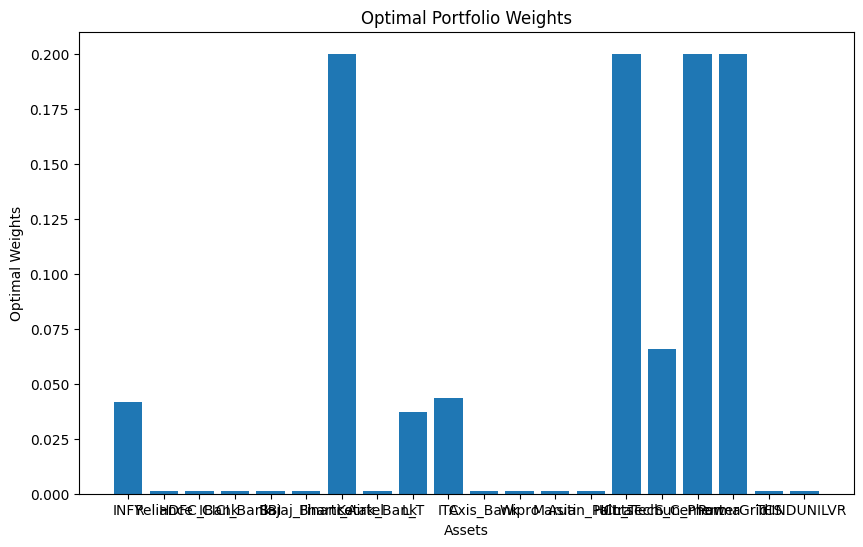

In [24]:
plt.figure(figsize=(10, 6))
plt.bar(tickers, optimal_weights)

plt.xlabel('Assets')
plt.ylabel('Optimal Weights')
plt.title('Optimal Portfolio Weights')

plt.show()

In [25]:
num_portfolios = 10000  # Number of portfolios to generate
np.random.seed(42)

all_weights = np.zeros((num_portfolios, len(tickers)))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

for i in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)  # Normalize to sum = 1

    all_weights[i, :] = weights
    ret_arr[i] = expected_return(weights, log_returns)
    vol_arr[i] = std_dev(weights, cov_matrix)
    sharpe_arr[i] = sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate)

# Save best Sharpe ratio portfolio
max_sharpe_idx = sharpe_arr.argmax()
sharpe_optimal_weights = all_weights[max_sharpe_idx]

# Save minimum volatility portfolio
min_vol_idx = vol_arr.argmin()
min_vol_weights = all_weights[min_vol_idx]


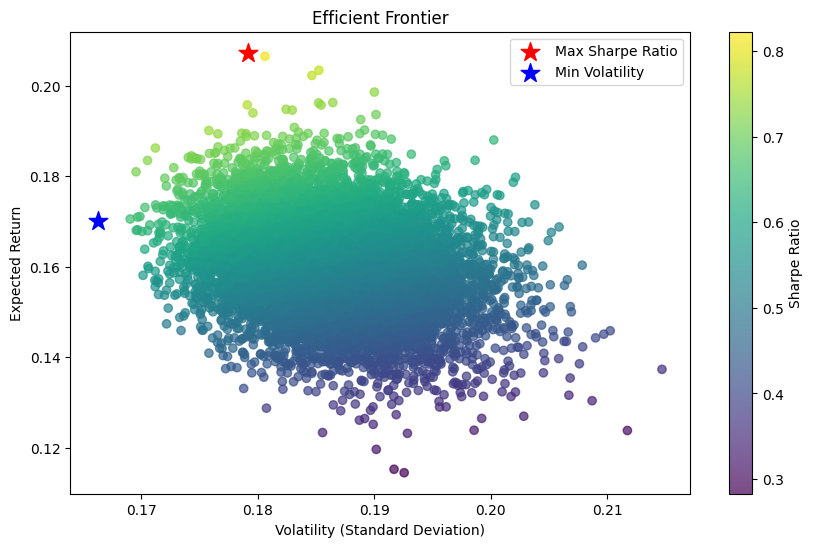

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', alpha=0.7)
plt.colorbar(label='Sharpe Ratio')

# Highlighting the best Sharpe ratio portfolio
plt.scatter(vol_arr[max_sharpe_idx], ret_arr[max_sharpe_idx], color='red', marker='*', s=200, label="Max Sharpe Ratio")

# Highlighting the minimum volatility portfolio
plt.scatter(vol_arr[min_vol_idx], ret_arr[min_vol_idx], color='blue', marker='*', s=200, label="Min Volatility")

plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.legend()
plt.show()


# For Minimum Volatility the Weights would be :

In [28]:
def min_volatility(weights, cov_matrix):
    return std_dev(weights, cov_matrix)

min_vol_results = minimize(
    min_volatility, initial_weights,
    args=(cov_matrix,),
    method='SLSQP',
    constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    bounds=bounds
)

min_vol_optimal_weights = min_vol_results.x
min_vol_optimal_weights 

array([0.001     , 0.001     , 0.07115645, 0.001     , 0.001     ,
       0.001     , 0.06173012, 0.001     , 0.001     , 0.11218676,
       0.001     , 0.01003813, 0.001     , 0.09443631, 0.01413785,
       0.001     , 0.1455992 , 0.13768068, 0.15088545, 0.19214906])